In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("Processed_Sales_data.csv")

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1237 entries, 0 to 1236
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Order Date          1237 non-null   object 
 1   Sales               1237 non-null   float64
 2   Year                1237 non-null   int64  
 3   Month               1237 non-null   int64  
 4   Day                 1237 non-null   int64  
 5   Day of week         1237 non-null   int64  
 6   Quarter             1237 non-null   int64  
 7   Time_Index          1237 non-null   int64  
 8   Avg of week         1237 non-null   float64
 9   Lag_1               1237 non-null   float64
 10  Lag_7               1237 non-null   float64
 11  Season              1237 non-null   object 
 12  Quantity            1237 non-null   int64  
 13  Furniture           1237 non-null   float64
 14  Office Supplies     1237 non-null   float64
 15  Technology          1237 non-null   float64
 16  Centra

In [5]:
features = [
    'Year',
    'Month',
    'Day',
    'Day of week',
    'Quarter',
    'Time_Index',
    'Avg of week',
    'Lag_1',
    'Lag_7',
    'Lag_14',
    'Lag_30',
    'Rolling_14',
    'Lag_7_rolling_mean',
    'Lag_14_rolling_std',
    'Qty_x_AvgWeek',
    'month_sin',
    'month_cos',
    'dow_sin',
    'dow_cos',
    'expanding_mean',
    'Season',
    'Quantity'
]

In [6]:
#Encoding categorical feature
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Season']=le.fit_transform(df['Season'])

print(df['Season'].dtypes)

int64


In [7]:
#-----DATA SPLITTING------
X=df[features]
y=df['Sales']

In [8]:
split_idx=int(len(df)*0.8)

X_train=X[:split_idx]
X_test=X[split_idx:]

y_train=y[:split_idx]
y_test=y[split_idx:]

In [9]:
print(X_train.shape)
print(X_test.shape)

print(X.info())

print(len(X.columns))

print(df.isnull().sum())

(989, 22)
(248, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1237 entries, 0 to 1236
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                1237 non-null   int64  
 1   Month               1237 non-null   int64  
 2   Day                 1237 non-null   int64  
 3   Day of week         1237 non-null   int64  
 4   Quarter             1237 non-null   int64  
 5   Time_Index          1237 non-null   int64  
 6   Avg of week         1237 non-null   float64
 7   Lag_1               1237 non-null   float64
 8   Lag_7               1237 non-null   float64
 9   Lag_14              1237 non-null   float64
 10  Lag_30              1237 non-null   float64
 11  Rolling_14          1237 non-null   float64
 12  Lag_7_rolling_mean  1237 non-null   float64
 13  Lag_14_rolling_std  1237 non-null   float64
 14  Qty_x_AvgWeek       1237 non-null   float64
 15  month_sin           1237 non-null  

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist_rf = {
    # Tree ensemble size
    'n_estimators': [200, 300, 500],

    # Tree complexity control
    'max_depth': [10, 15, 20, None],

    # Minimum samples to split / leaf
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],

    # Feature sampling
    'max_features': ['sqrt', 0.5, 0.7],

    # Row sampling per tree (important for generalization)
    'max_samples': [0.7, 0.8, 0.9],

    # Split quality function
    'criterion': ['squared_error', 'absolute_error'],

    # Noise control (light regularization only)
    'min_impurity_decrease': [0.0, 0.01],

    # Tree shape control (keep small range only)
    'max_leaf_nodes': [None, 100, 200]
}

from sklearn.ensemble import RandomForestRegressor

search_rf = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=25,
    cv=5,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_rf.fit(X_train, y_train)

print(search_rf.best_params_)

In [ ]:
rf_model = search.best_estimator_

rf_pred = rf_model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R²:", r2_score(y_test, rf_pred))

In [ ]:
#pip install lightgbm

In [10]:
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    # --- Tree structure ---
    'n_estimators':       [500, 800, 1000, 1500],
    'max_depth':          [-1, 6, 8, 10, 15],      # -1 = no limit
    'num_leaves':         [31, 63, 127, 255],       # main complexity control
    'min_child_samples':  [10, 20, 30, 50],         # min data in leaf

    # --- Learning ---
    'learning_rate':      [0.01, 0.03, 0.05, 0.1],
    'boosting_type':      ['gbdt', 'dart'],         # dart = dropout trees

    # --- Sampling (reduces overfitting) ---
    'subsample':          [0.6, 0.7, 0.8, 0.9],    # row sampling
    'subsample_freq':     [1, 5],                   # apply subsample every N iters
    'colsample_bytree':   [0.6, 0.7, 0.8, 0.9],    # feature sampling per tree

    # --- Regularization ---
    'reg_alpha':          [0, 0.01, 0.1, 0.5, 1.0],  # L1
    'reg_lambda':         [0, 0.01, 0.1, 0.5, 1.0],  # L2
    'min_split_gain':     [0.0, 0.01, 0.05, 0.1],    # min gain to split

    # --- Target specific ---
    'objective':          ['regression',             # optimizes RMSE
                           'regression_l1',          # optimizes MAE
                           'huber',                  # robust to outliers
                           'poisson'],               # for count/demand data
}

In [11]:
#--------MODEL CROSS VALIDATION--------
search_lgbm = RandomizedSearchCV(
    LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    param_dist,
    n_iter=60,
    cv=5,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search_lgbm.fit(X_train, y_train)

print("Best params:", search_lgbm.best_params_)
print("Best MAE:   ", -search_lgbm.best_score_)

best_params_lgbm = search_lgbm.best_params_

# Separate n_estimators out — early stopping will find optimal count
best_params_lgbm['n_estimators'] = 2000   # set high, early stopping will cut it

lgbm_model = LGBMRegressor(**best_params_lgbm, random_state=42, n_jobs=-1)



Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best params: {'subsample_freq': 5, 'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'objective': 'regression_l1', 'num_leaves': 255, 'n_estimators': 500, 'min_split_gain': 0.01, 'min_child_samples': 50, 'max_depth': 15, 'learning_rate': 0.01, 'colsample_bytree': 0.8, 'boosting_type': 'gbdt'}
Best MAE:    863.0265383364562


In [14]:
#-------MODEL TRAIN-TEST--------
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(100)
    ]
)

print(f"Optimal trees used: {lgbm_model.best_iteration_}")

lgbm_pred = lgbm_model.predict(X_test)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's l1: 1235
[200]	valid_0's l1: 1132.31
[300]	valid_0's l1: 1113.63
Early stopping, best iteration is:
[324]	valid_0's l1: 1112.59
Optimal trees used: 324


In [15]:
#-------MODEL EVALUATION---------
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, lgbm_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lgbm_pred)))
print("R²:", r2_score(y_test, lgbm_pred))

MAE: 1112.5888588404457
RMSE: 1765.5190078864769
R²: 0.48777512058516115


In [ ]:
from lightgbm import LGBMRegressor          # pip install lightgbm
import lightgbm as lgb
lgbm_model2 = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1
)
# Early stopping to avoid overfitting
lgbm_model2.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])

lgbm_pred2 = lgbm_model2.predict(X_test)

print("MAE:", mean_absolute_error(y_test, lgbm_pred2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lgbm_pred2)))
print("R²:", r2_score(y_test, lgbm_pred2))

In [16]:
search=search_lgbm
best_model = lgbm_model

In [17]:
pred = best_model.predict(X_test)

In [18]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

print(importance)

               Feature  Importance
14       Qty_x_AvgWeek         637
21            Quantity         586
7                Lag_1         295
10              Lag_30         258
9               Lag_14         254
6          Avg of week         253
8                Lag_7         205
19      expanding_mean         203
11          Rolling_14         201
2                  Day         184
13  Lag_14_rolling_std         182
12  Lag_7_rolling_mean         179
5           Time_Index         159
1                Month         113
17             dow_sin          69
3          Day of week          68
15           month_sin          61
18             dow_cos          43
16           month_cos          37
20              Season           7
4              Quarter           6
0                 Year           6


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R²:", r2_score(y_test, pred))

MAE: 1112.5888588404457
RMSE: 1765.5190078864769
R²: 0.48777512058516115


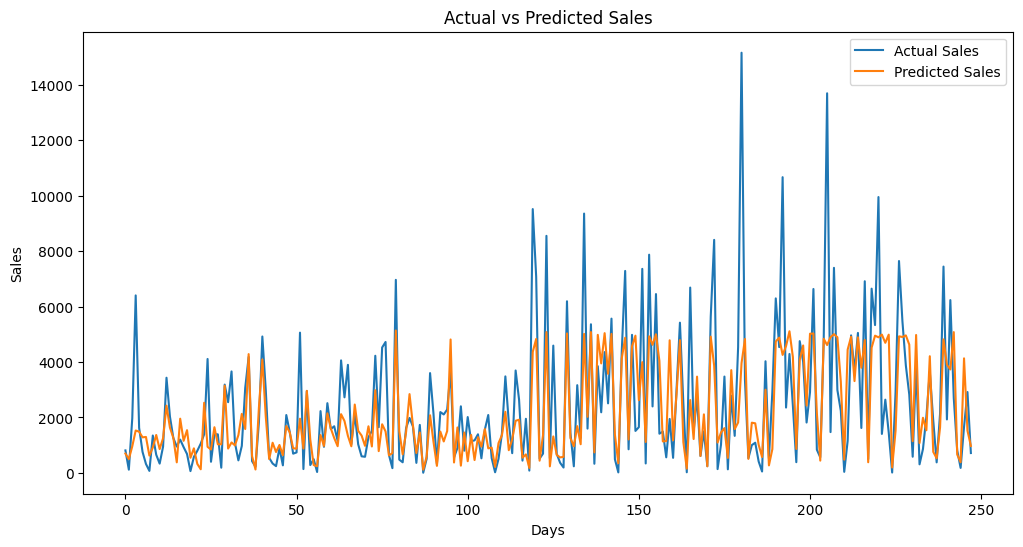

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual Sales')
plt.plot(pred, label='Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.xlabel('Days')
plt.ylabel('Sales')
plt.legend()
plt.savefig("actual_vs_predicted_sales.png", dpi=300, bbox_inches='tight')
plt.show()

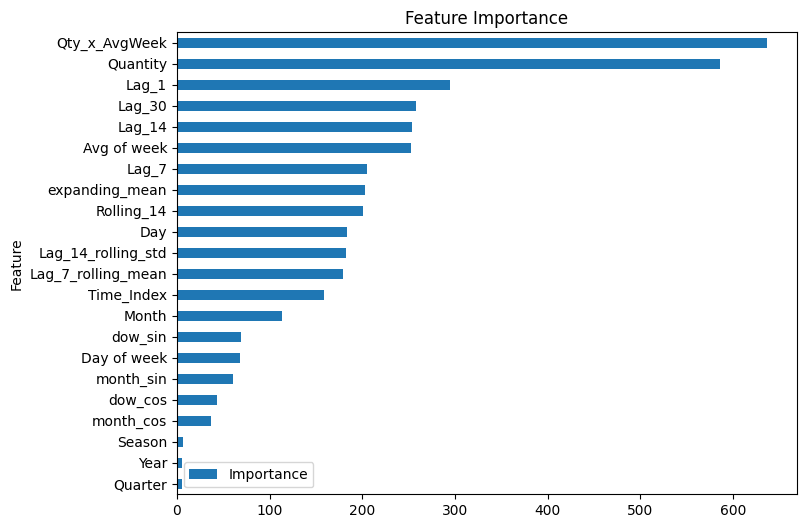

In [21]:
importance.sort_values(
    'Importance'
).plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(8,6)
)

plt.title('Feature Importance')
plt.savefig("feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

In [22]:
#save best model
import joblib

joblib.dump(lgbm_model, "sales_forecast_model.pkl")
joblib.dump(list(X_train.columns), "feature_names.pkl")
print(len(X_train.columns.tolist()))
print(X_train.shape)

22
(989, 22)


In [23]:
#Error analysis
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': pred
})

results['Error'] = results['Actual'] - results['Predicted']
results['Absolute_Error'] = abs(results['Error'])

results.head()

,Actual,Predicted,Error,Absolute_Error
989,808.4700,691.782873,116.687127,116.687127
990,114.4200,494.510030,-380.090030,380.090030
991,1971.2905,957.572018,1013.718482,1013.718482
992,6401.9300,1526.662885,4875.267115,4875.267115
993,1626.7100,1485.739744,140.970256,140.970256


In [24]:
worst_errors = results.sort_values(
    by='Absolute_Error',
    ascending=False
)

print(worst_errors.head(10))

          Actual    Predicted         Error  Absolute_Error
1169  15158.8770  3960.855051  11198.021949    11198.021949
1194  13694.8828  4610.877450   9084.005350     9084.005350
1181  10668.0960  4254.641214   6413.454786     6413.454786
1108   9517.2880  4366.588279   5150.699721     5150.699721
1209   9951.1820  4889.773203   5061.408797     5061.408797
992    6401.9300  1526.662885   4875.267115     4875.267115
1161   8405.8020  3865.369390   4540.432610     4540.432610
1123   9354.8540  5013.199791   4341.654209     4341.654209
1154   6684.6160  2626.414560   4058.201440     4058.201440
1210   1403.8420  4988.428535  -3584.586535     3584.586535


In [25]:
mape = (
    np.mean(
        np.abs((y_test - pred) / y_test)
    ) * 100
)

print("MAPE:", mape)

MAPE: 119.49106257982586


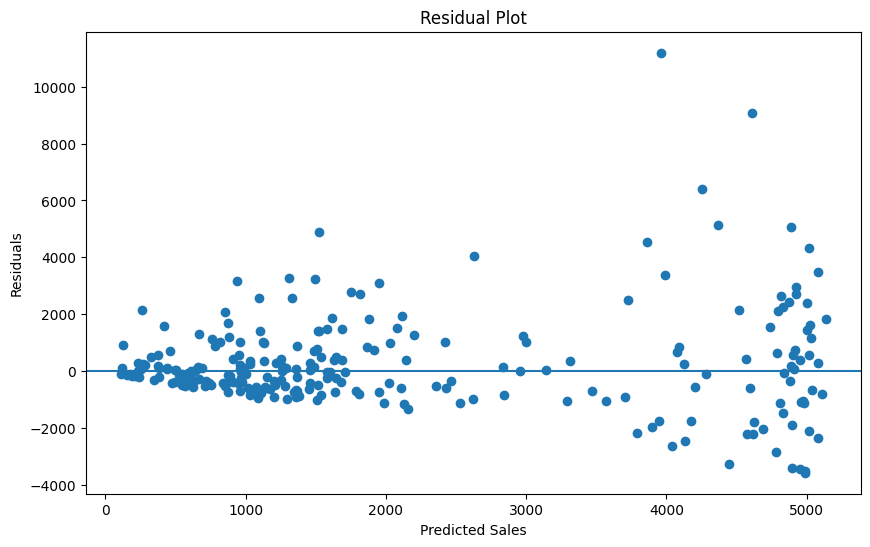

In [26]:
residuals = y_test - pred

plt.figure(figsize=(10,6))
plt.scatter(pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.savefig("residual_plot.png", dpi=300, bbox_inches='tight')
plt.show()

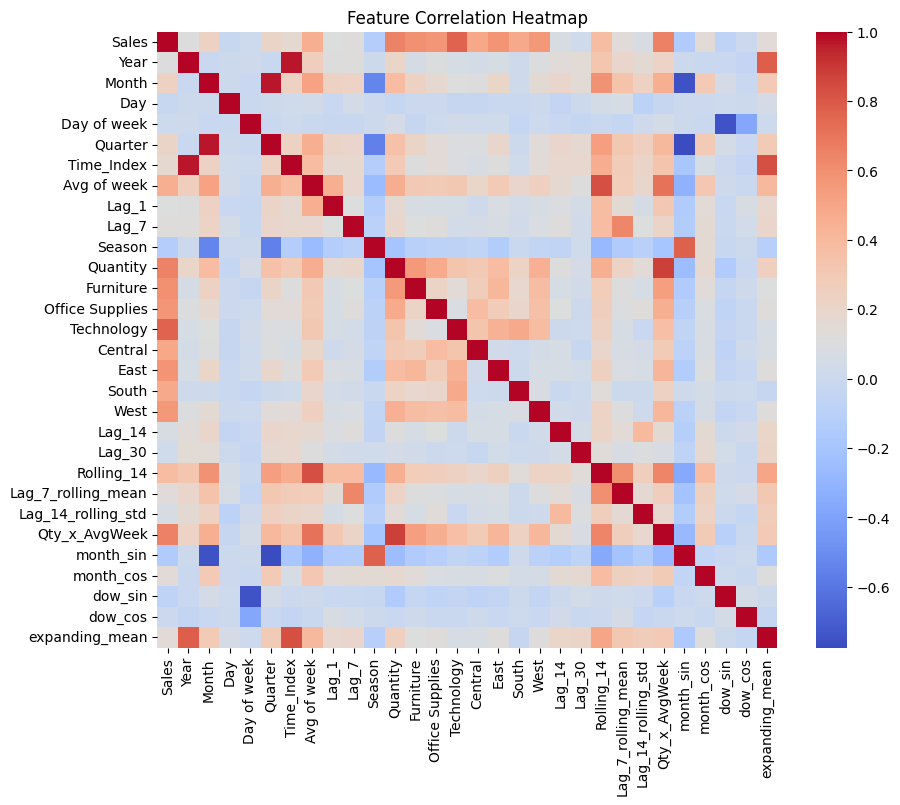

In [27]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include='number').corr(),
            cmap='coolwarm',
            annot=False)

plt.title('Feature Correlation Heatmap')
plt.savefig("feature_correlation.png", dpi=300, bbox_inches='tight')
plt.show()

In [40]:
import pandas as pd
pred_df = pd.DataFrame({
    'Date': X_test.index if hasattr(X_test.index, 'dtype') else range(len(y_test)),
    'Actual Sales': y_test.values,
    'Predicted Sales': pred
})

pred_df['Residual'] = pred_df['Actual Sales'] - pred_df['Predicted Sales']

pred_df.to_csv('predictions_tableau.csv')

print(pred_df.head())

   Date  Actual Sales  Predicted Sales     Residual
0   989      808.4700       691.782873   116.687127
1   990      114.4200       494.510030  -380.090030
2   991     1971.2905       957.572018  1013.718482
3   992     6401.9300      1526.662885  4875.267115
4   993     1626.7100      1485.739744   140.970256


In [37]:
importance.to_csv("feature_importance.csv")

In [38]:
df.to_csv("trained_sales_data.csv",index=False)

In [39]:
pred_df

,Date,Actual Sales,Predicted Sales,Residual
0,989,808.4700,691.782873,116.687127
1,990,114.4200,494.510030,-380.090030
2,991,1971.2905,957.572018,1013.718482
3,992,6401.9300,1526.662885,4875.267115
4,993,1626.7100,1485.739744,140.970256
...,...,...,...,...
243,1232,814.5940,661.891431,152.702569
244,1233,177.6360,381.289064,-203.653064
245,1234,1657.3508,4131.069089,-2473.718289
246,1235,2915.5340,1523.753448,1391.780552
